In [128]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
 tarball_path = Path("datasets/housing.tgz")
 if not tarball_path.is_file():
    Path("datasets").mkdir(parents=True, exist_ok=True)
    url = "https://github.com/ageron/data/raw/main/housing.tgz"
    urllib.request.urlretrieve(url, tarball_path)
 with tarfile.open(tarball_path) as housing_tarball:
    housing_tarball.extractall(path="datasets")
 return pd.read_csv(Path("datasets/housing/housing.csv"))
housing = load_housing_data()


C:\Users\abs\AppData\Local\Temp\ipykernel_2820\1989022933.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [129]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

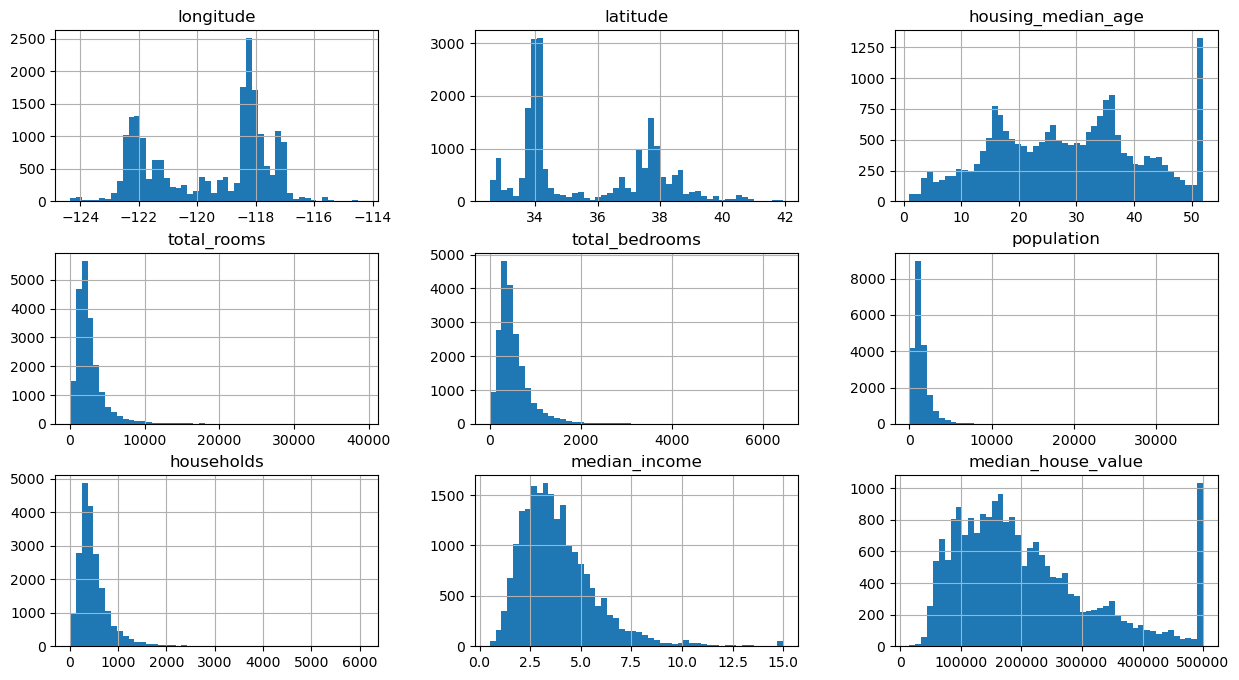

In [130]:

housing.hist(bins=50, figsize=(15, 8))
plt.show()

In [131]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [132]:
housing['income_cat'] = pd.cut(housing['median_income'], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])

In [133]:
housing['income_cat'].dtype

CategoricalDtype(categories=[1, 2, 3, 4, 5], ordered=True, categories_dtype=int64)

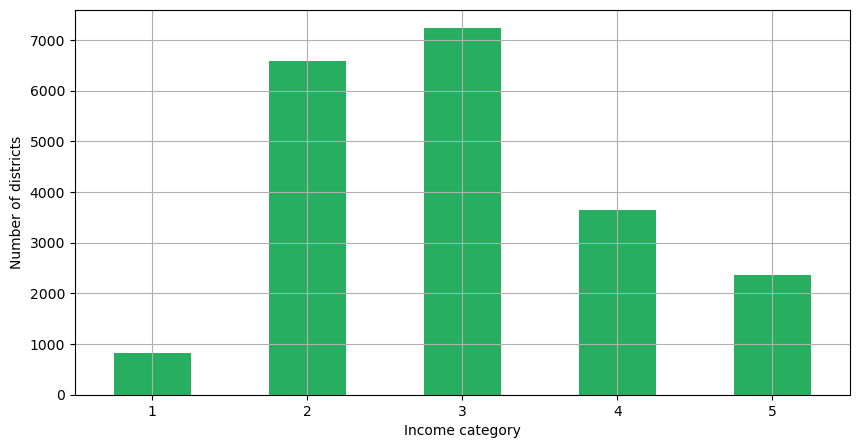

In [134]:
fig, ax = plt.subplots(figsize=(10, 5))
housing['income_cat'].value_counts().sort_index().plot(kind='bar', color='#27ae60', ax=ax)
ax.set_xlabel("Income category")
ax.set_ylabel("Number of districts")
ax.grid()
ax.tick_params(axis='x', labelrotation=0)

In [135]:
from sklearn.model_selection import train_test_split



strat_train_set, strat_test = train_test_split(housing, test_size=0.2, stratify=housing['income_cat'], random_state=42)

In [136]:
strat_train_set['income_cat'].value_counts() / len(X_test)

income_cat
3    1.402374
2    1.275436
4    0.705184
5    0.457849
1    0.159157
Name: count, dtype: float64

# Discover and Visualize the Data to Gain Insights


In [137]:
housing = strat_train_set.copy()

<Axes: xlabel='latitude', ylabel='longitude'>

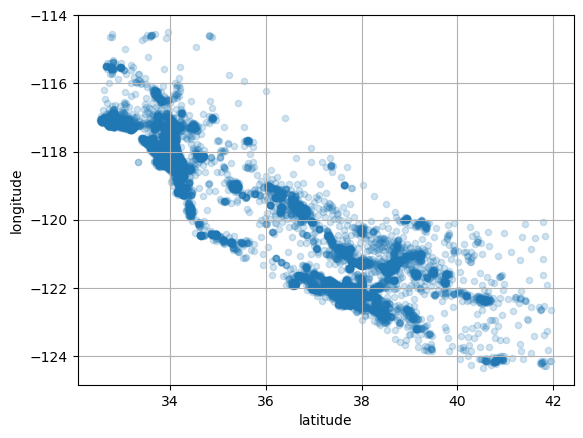

In [138]:
housing.plot(kind='scatter', x='latitude', y='longitude', grid=True, alpha=0.2)

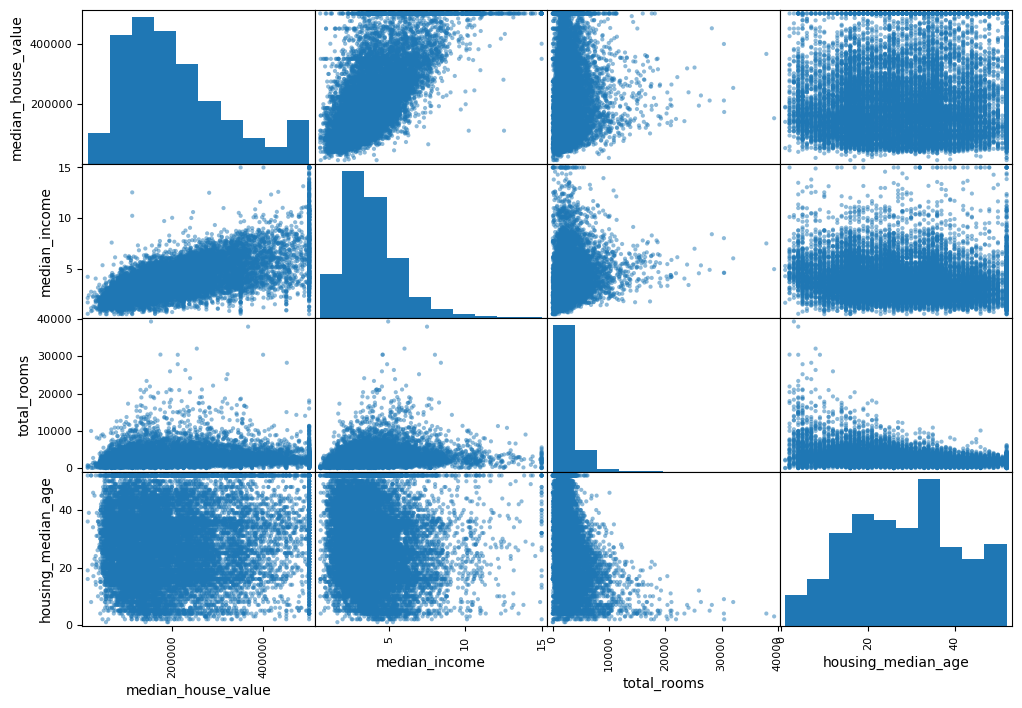

In [139]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income","total_rooms",
 "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()


In [140]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [141]:
housing.select_dtypes(include=['int64', 'float64']).corr()['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

In [142]:
housing = strat_train_set.drop('median_house_value', axis=1)
housing_labels = strat_train_set['median_house_value'].copy()

In [144]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
housing_num = housing.select_dtypes(include=['int64', 'float64'])
imputer.fit(housing_num)
print(imputer.statistics_)
X = imputer.transform(housing_num)

[-118.51     34.26     29.     2125.      434.     1167.      408.
    3.5385]


In [ ]:
housing_cat = housing.select_dtypes(include=['object'])


,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
...,...
14207,<1H OCEAN
13105,INLAND
19301,NEAR OCEAN
19121,<1H OCEAN


In [150]:
from sklearn.preprocessing import OneHotEncoder

housing_cat_encoded = OneHotEncoder(handle_unknown='ignore').fit_transform(housing_cat)

In [151]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)